# Topological Transitions

## Sliding Windows

Financial markets are dynamic so we focus on a fixed number of recent periods to analyze time series. We apply sliding windows that consist of a fixed size of consecutive points in time and move forward one step in time. Each window of size (w,4) is our point cloud in 4D.

### Sliding Window Size

We are taking w = 50 and w = 100 following Gidea & Katz.

In [3]:
import pandas as pd
import numpy as np
import yfinance as yf
import math as mt

In [4]:
# Download historical data for the S&P 500, NASDAQ, Dow Jones Industrial Average, and Russell 2000 indices from 1999 to 2021
SP500 = yf.download("^GSPC", start="1999-01-01", end="2021-12-31")
NASDAQ = yf.download("^IXIC", start="1999-01-01", end="2021-12-31")
DJIA = yf.download("^DJI", start="1999-01-01", end="2021-12-31")
RUSSELL2000 = yf.download("^RUT", start="1999-01-01", end="2021-12-31")

# Assets returns
SP500_returns = np.log(SP500["Close"]/SP500["Close"].shift(1))
NASDAQ_returns = np.log(NASDAQ["Close"]/NASDAQ["Close"].shift(1))
DJIA_returns = np.log(DJIA["Close"]/DJIA["Close"].shift(1))
RUSSELL2000_returns = np.log(RUSSELL2000["Close"]/RUSSELL2000["Close"].shift(1))

# Combine the returns into a single DataFrame and clean
market_returns = pd.concat([SP500_returns, NASDAQ_returns, DJIA_returns, RUSSELL2000_returns], axis=1)
market_returns.dropna(inplace=True)
market_returns.rename(columns={"^GSPC": "SP500", "^IXIC": "NASDAQ", "^DJI": "DJIA", "^RUT": "Russell2000"}, inplace=True)



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [5]:
# Slicing window size
w = 50

# Slicing windows function
def slicing_windows(DataFrame, t, w):
    if t < 0 or t > len(DataFrame) - w:
        raise ValueError("Invalid starting index for slicing windows.")
    else:    
        point_cloud = DataFrame.iloc[t:t+w].values
    return point_cloud

In [6]:
all_windows = []
for t in range(len(market_returns) - w + 1):
    window = slicing_windows(market_returns, t, w)
    all_windows.append(window)

## Persistence Diagrams

*Persistence diagrams* calculate the amount and duration of loops (H1) and connected components (H0) in our space.

In [7]:
from ripser import ripser
from persim import plot_diagrams
import matplotlib.pyplot as plt

In [8]:
results = ripser(all_windows[0])
diagrams = results['dgms']

H0: (50, 2)
H1: (9, 2)


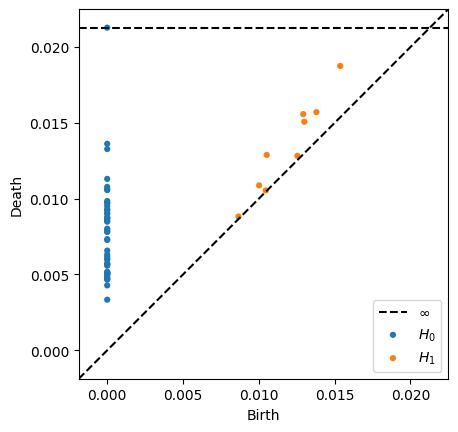

In [9]:
print("H0:", diagrams[0].shape) # H0 
print("H1:", diagrams[1].shape) # H1
plot_diagrams(diagrams, show=True)


## Observations

The persistence diagrams tell us that it has a diameter of approximately 0.021, and that 9 loops formed, but we have 4 of them really close to the line that represent noise and don't have significant topological features.

In [10]:
%%time

persistence_diagrams = []

for i in range(len(all_windows)):
    results = ripser(all_windows[i])
    diagrams = results['dgms']
    persistence_diagrams.append(diagrams)
    

CPU times: user 18.8 s, sys: 38.5 ms, total: 18.9 s
Wall time: 18.9 s


In [11]:

print(len(persistence_diagrams))
print(persistence_diagrams[0][1].shape)  # H1 of first window

5737
(9, 2)


We have calculated 5737 persistence diagrams for each of our windows. We verified that `persistence_diagrams[0][1]` coincides with what we had already calculated.

In `persistence_diagrams[i][1]` we have the amount of loops (H1) that were born and died in the window "i". We'll use this to calculate persistence landscapes and $L^2$ norms.

In [12]:
market_returns.index.get_loc("2005-01-03")

1507

In [13]:
market_returns.index.get_loc("2008-10-01")

2450

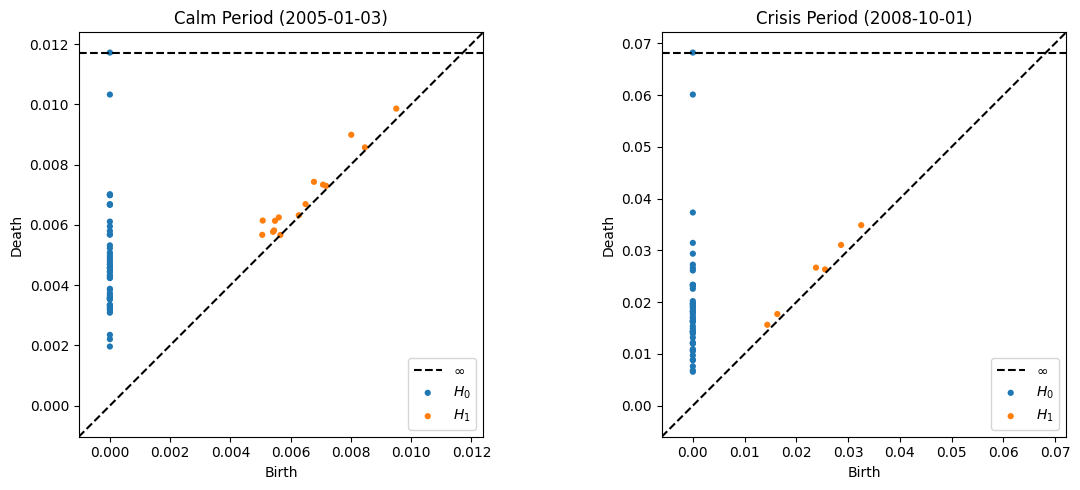

In [16]:
calm_results = persistence_diagrams[market_returns.index.get_loc("2005-01-03")]
crisis_results = persistence_diagrams[market_returns.index.get_loc("2008-10-01")]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plot_diagrams(calm_results, ax=axes[0], show=False)
axes[0].set_title("Calm Period (2005-01-03)")

plot_diagrams(crisis_results, ax=axes[1], show=False)
axes[1].set_title("Crisis Period (2008-10-01)")

plt.tight_layout()
plt.show()

In [17]:
calm_h1 = calm_results[1]
crisis_h1 = crisis_results[1]

print("Calm H1 persistence:")
print(calm_h1[:, 1] - calm_h1[:, 0])

print("\nCrisis H1 persistence:")
print(crisis_h1[:, 1] - crisis_h1[:, 0])

Calm H1 persistence:
[3.51953320e-04 1.05780549e-04 9.78377648e-04 1.11502595e-04
 2.59155408e-04 6.54913019e-04 1.92876905e-04 4.68920916e-05
 5.00585884e-06 6.39664009e-04 6.53575175e-04 3.65794636e-04
 3.51497438e-04 1.06877973e-03 6.11577649e-04]

Crisis H1 persistence:
[0.00233599 0.00240174 0.0007655  0.00287284 0.00137559 0.00123668]


We can see the both diagrams side by side, a calm period against a crisis period.

### Observations

The crisis period has a longer diameter of ~0.07 than the calm period of ~0.012 and its loops live longer, ~0.003 against ~0.001 in the lifespan of the longest loops. The higher number of loops in the calm period should not be mistaken for meaningful structure, some of it is just insignificant noise.